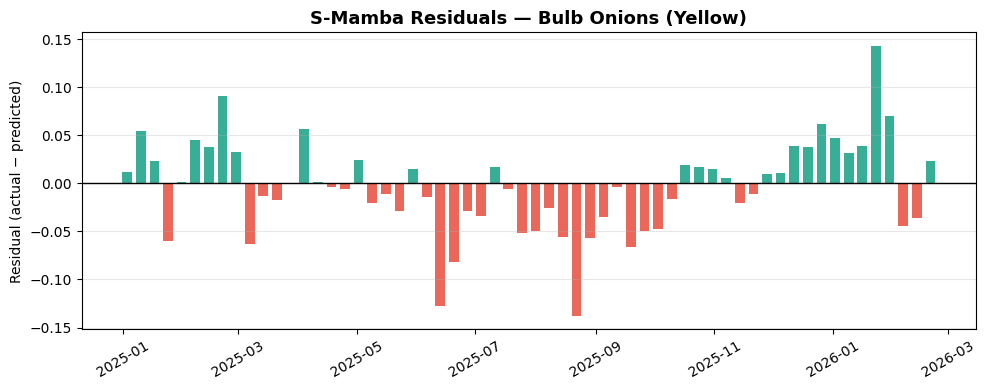

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('../..').resolve()

df = pd.read_csv(BASE / 'outputs/predictions/smamba_forecasts.csv', parse_dates=['date'])
df['error'] = df['actual'] - df['predicted']

sub = df[df['commodity'] == 'Bulb Onions (Yellow)'].sort_values('date')

COLOR = '#16a085'
fig, ax = plt.subplots(figsize=(10, 4))

bar_colors = [COLOR if e >= 0 else '#e74c3c' for e in sub['error']]
ax.bar(sub['date'], sub['error'], color=bar_colors, width=5, alpha=0.85)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('S-Mamba Residuals — Bulb Onions (Yellow)', fontsize=13, fontweight='bold')
ax.set_ylabel('Residual (actual − predicted)')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()